# Results — tables and figures

Builds every table and figure used in Chapter 5 from the three result files produced by
the training notebooks.

**Inputs**

- `../results/baselines_results.csv` — Random Forest and XGBoost
- `../results/stl_results.csv` — single-task LSTM
- `../results/mtl_results.csv` — multi-task LSTM, joint and cascaded

**Outputs**

- LaTeX tables into `../tables/`, pulled into the thesis with `\input{}`
- figures into `../imgs/`

Computational efficiency metrics are deliberately not reported.

In [1]:
!pip install numpy pandas matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


## Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

RESULTS_DIR = "../results"
IMG_DIR     = "../imgs"
TABLE_DIR   = "../tables"
DPI         = 200

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

FAULT_TYPES = ["clogged_filters", "cooling_fault", "valve_fault", "bearing_fault"]
FAULT_LABELS = {
    "clogged_filters": "Clogged filters",
    "cooling_fault":   "Cooling fault",
    "valve_fault":     "Valve fault",
    "bearing_fault":   "Bearing fault",
}

# display name -> (colour, marker), also fixes the column order in every table
MODELS = {
    "Random Forest":  ("#8c564b", "o"),
    "XGBoost":        ("#e377c2", "s"),
    "STL":            ("#1f77b4", "^"),
    "MTL (joint)":    ("#ff7f0e", "v"),
    "MTL (cascaded)": ("#2ca02c", "D"),
}

baselines = pd.read_csv(os.path.join(RESULTS_DIR, "baselines_results.csv"))
stl       = pd.read_csv(os.path.join(RESULTS_DIR, "stl_results.csv"))
mtl       = pd.read_csv(os.path.join(RESULTS_DIR, "mtl_results.csv"))

print(f"baselines : {len(baselines):>3} rows, window sizes {sorted(baselines.window_size.unique())}")
print(f"stl       : {len(stl):>3} rows, window sizes {sorted(stl.window_size.unique())}")
print(f"mtl       : {len(mtl):>3} rows, window sizes {sorted(mtl.window_size.unique())}")

baselines :  46 rows, window sizes [1, 2, 4, 8, 16, 32, 64, 128]
stl       :  33 rows, window sizes [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
mtl       :  22 rows, window sizes [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]


## Helpers

`metric_table` assembles one table with a row per window size and a column per model. The
metric is named differently in each result file, so the mapping is resolved here rather
than at every call site.

In [3]:
# metric name in the STL/baseline files -> metric name in the MTL file
MTL_NAME = {
    "f1": "ad_f1", "precision": "ad_precision", "recall": "ad_recall",
    "accuracy": "ad_accuracy", "roc_auc": "ad_roc_auc",
    "mean_f1": "fd_mean_f1",
    "mae": "pdm_mae", "rmse": "pdm_rmse", "r2": "pdm_r2",
}
LOWER_IS_BETTER = {"mae", "rmse", "pdm_mae", "pdm_rmse"}


def metric_table(task, metric):
    """One row per window size, one column per model."""
    out = {}
    for name, key in [("Random Forest", "random_forest"), ("XGBoost", "xgboost")]:
        sel = baselines[(baselines.task == task) & (baselines.model_name == key)]
        out[name] = sel.set_index("window_size")[metric]
    out["STL"] = stl[stl.task == task].set_index("window_size")[metric]
    for name, arch in [("MTL (joint)", "joint"), ("MTL (cascaded)", "cascaded")]:
        sel = mtl[mtl.architecture == arch]
        out[name] = sel.set_index("window_size")[MTL_NAME[metric]]
    table = pd.DataFrame(out)[list(MODELS)]
    return table.sort_index()


def best_of(series, metric):
    """(window size, value) of the best entry, respecting the metric's direction."""
    s = series.dropna()
    idx = s.idxmin() if metric in LOWER_IS_BETTER else s.idxmax()
    return int(idx), float(s.loc[idx])


def write_latex_table(table, metric, filename, caption_note=""):
    """Emit a tabular with the best value per column in bold and '--' for gaps."""
    best_idx = {c: best_of(table[c], metric)[0] for c in table.columns}
    lines = [
        f"% Auto-generated by results.ipynb -- do not edit by hand{caption_note}",
        r"\begin{tabular}{l" + "r" * len(table.columns) + "}",
        r"\hline",
        r"\textbf{Window size} & " + " & ".join(rf"\textbf{{{c}}}" for c in table.columns) + r" \\",
        r"\hline",
    ]
    for ws, row in table.iterrows():
        cells = []
        for c in table.columns:
            v = row[c]
            if pd.isna(v):
                cells.append("--")
            elif ws == best_idx[c]:
                cells.append(rf"\textbf{{{v:.3f}}}")
            else:
                cells.append(f"{v:.3f}")
        lines.append(f"{ws:,} & " + " & ".join(cells) + r" \\")
    lines += [r"\hline", r"\end{tabular}"]

    path = os.path.join(TABLE_DIR, filename)
    with open(path, "w") as fh:
        fh.write("\n".join(lines) + "\n")
    print(f"wrote {path}")


def plot_metric(table, metric, ylabel, title, filename, ax=None):
    """Metric against window size, one line per model, log-scaled x axis."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 5))
    for name, (colour, marker) in MODELS.items():
        s = table[name].dropna()
        ax.plot(s.index, s.values, marker=marker, color=colour, linewidth=1.6,
                markersize=5, label=name)
    ax.set_xscale("log", base=2)
    ax.set_xticks(table.index)
    ax.set_xticklabels(table.index, rotation=0)
    ax.set_xlabel("Window size (observations)")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)
    if standalone:
        ax.legend(fontsize=9)
        fig.tight_layout()
        path = os.path.join(IMG_DIR, filename)
        fig.savefig(path, dpi=DPI, bbox_inches="tight")
        print(f"wrote {path}")
        plt.show()
    return ax


print("Helpers defined")

Helpers defined


## Anomaly detection

Feeds `Table~\ref{tab:results_ad_f1}`, `Table~\ref{tab:results_ad_roc}` and
`Figure~\ref{fig:results_ad}`.

In [4]:
ad_f1  = metric_table("ad", "f1")
ad_roc = metric_table("ad", "roc_auc")

write_latex_table(ad_f1,  "f1",      "results_ad_f1.tex")
write_latex_table(ad_roc, "roc_auc", "results_ad_roc.tex")

print("\nBest F1 per model")
for c in ad_f1.columns:
    ws, v = best_of(ad_f1[c], "f1")
    print(f"  {c:<16} {v:.3f}  at window size {ws}")

ad_f1.round(3)

wrote ../tables/results_ad_f1.tex
wrote ../tables/results_ad_roc.tex

Best F1 per model
  Random Forest    0.441  at window size 32
  XGBoost          0.460  at window size 32
  STL              0.900  at window size 64
  MTL (joint)      0.885  at window size 128
  MTL (cascaded)   0.889  at window size 128


,Random Forest,XGBoost,STL,MTL (joint),MTL (cascaded)
window_size,,,,,
1,0.239,0.248,0.836,0.798,0.806
2,0.268,0.273,0.814,0.810,0.802
4,0.289,0.313,0.805,0.805,0.812
8,0.315,0.352,0.814,0.857,0.822
16,0.419,0.420,0.781,0.822,0.832
32,0.441,0.460,0.865,0.868,0.850
64,0.396,0.347,0.900,0.826,0.872
128,0.353,0.328,0.857,0.885,0.889
256,NaN,NaN,0.897,0.881,0.871


wrote ../imgs/results_ad_f1.png


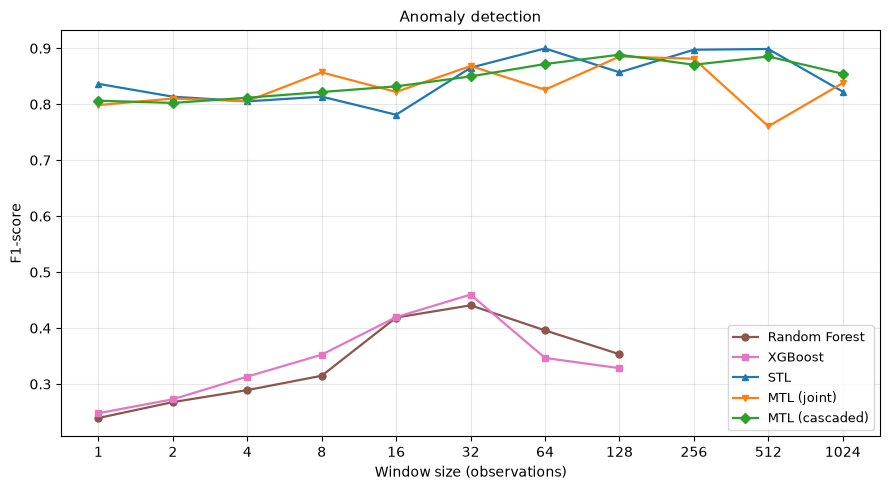

<Axes: title={'center': 'Anomaly detection'}, xlabel='Window size (observations)', ylabel='F1-score'>

In [5]:
plot_metric(ad_f1, "f1", "F1-score", "Anomaly detection", "results_ad_f1.png")

## Fault detection

Feeds `Table~\ref{tab:results_fd_f1}`, `Table~\ref{tab:results_fd_perfault}`,
`Figure~\ref{fig:results_fd}` and `Figure~\ref{fig:results_fd_perfault}`.

In [6]:
fd_f1 = metric_table("fd", "mean_f1")
write_latex_table(fd_f1, "mean_f1", "results_fd_f1.tex")

print("\nBest mean F1 per model")
best_fd_ws = {}
for c in fd_f1.columns:
    ws, v = best_of(fd_f1[c], "mean_f1")
    best_fd_ws[c] = ws
    print(f"  {c:<16} {v:.3f}  at window size {ws}")

fd_f1.round(3)

wrote ../tables/results_fd_f1.tex

Best mean F1 per model
  Random Forest    0.483  at window size 32
  XGBoost          0.504  at window size 64
  STL              0.701  at window size 16
  MTL (joint)      0.640  at window size 256
  MTL (cascaded)   0.720  at window size 64


,Random Forest,XGBoost,STL,MTL (joint),MTL (cascaded)
window_size,,,,,
1,0.248,0.226,0.545,0.584,0.544
2,0.256,0.238,0.511,0.587,0.563
4,0.274,0.320,0.516,0.492,0.521
8,0.358,0.354,0.623,0.605,0.562
16,0.439,0.422,0.701,0.602,0.553
32,0.483,0.471,0.572,0.579,0.613
64,0.475,0.504,0.553,0.626,0.720
128,0.465,0.323,0.578,0.604,0.569
256,NaN,NaN,0.560,0.640,0.670


wrote ../imgs/results_fd_f1.png


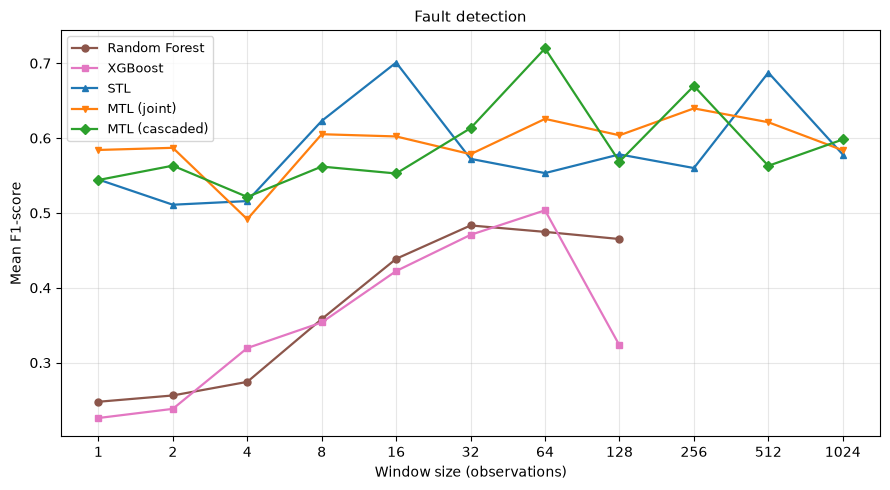

<Axes: title={'center': 'Fault detection'}, xlabel='Window size (observations)', ylabel='Mean F1-score'>

In [7]:
plot_metric(fd_f1, "mean_f1", "Mean F1-score", "Fault detection", "results_fd_f1.png")

In [8]:
# per-fault breakdown, each model taken at its own best window size
rows = {}
for name in MODELS:
    ws = best_fd_ws[name]
    if name in ("Random Forest", "XGBoost"):
        key = "random_forest" if name == "Random Forest" else "xgboost"
        r = baselines[(baselines.task == "fd") & (baselines.model_name == key)
                      & (baselines.window_size == ws)].iloc[0]
    elif name == "STL":
        r = stl[(stl.task == "fd") & (stl.window_size == ws)].iloc[0]
    else:
        arch = "joint" if "joint" in name else "cascaded"
        r = mtl[(mtl.architecture == arch) & (mtl.window_size == ws)].iloc[0]
    rows[f"{name} (ws={ws})"] = {FAULT_LABELS[f]: r[f"f1_{f}"] for f in FAULT_TYPES}

perfault = pd.DataFrame(rows)

lines = [
    "% Auto-generated by results.ipynb -- do not edit by hand",
    r"\begin{tabular}{l" + "r" * len(perfault.columns) + "}",
    r"\hline",
    r"\textbf{Fault type} & " + " & ".join(rf"\textbf{{{c}}}" for c in perfault.columns) + r" \\",
    r"\hline",
]
for ft, row in perfault.iterrows():
    lines.append(f"{ft} & " + " & ".join(f"{v:.3f}" for v in row) + r" \\")
lines += [r"\hline", r"\end{tabular}"]
with open(os.path.join(TABLE_DIR, "results_fd_perfault.tex"), "w") as fh:
    fh.write("\n".join(lines) + "\n")
print("wrote", os.path.join(TABLE_DIR, "results_fd_perfault.tex"))

perfault.round(3)

wrote ../tables/results_fd_perfault.tex


,Random Forest (ws=32),XGBoost (ws=64),STL (ws=16),MTL (joint) (ws=256),MTL (cascaded) (ws=64)
Clogged filters,0.079,0.142,0.769,0.792,0.841
Cooling fault,0.723,0.758,0.828,0.810,0.815
Valve fault,0.634,0.630,0.688,0.660,0.855
Bearing fault,0.498,0.484,0.518,0.297,0.368


wrote ../imgs/results_fd_perfault.png


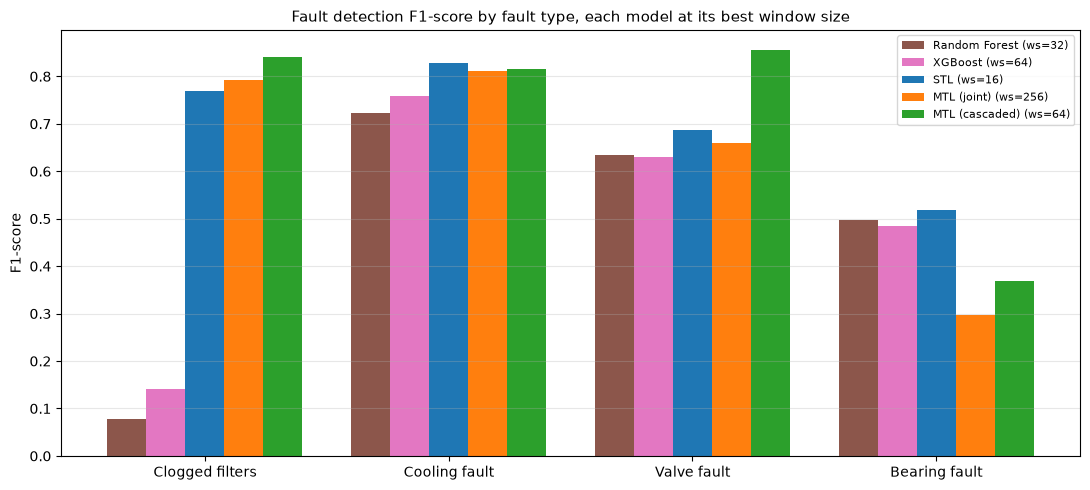

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(FAULT_TYPES))
width = 0.16

for i, (name, (colour, _)) in enumerate(MODELS.items()):
    ws = best_fd_ws[name]
    vals = perfault[f"{name} (ws={ws})"].values
    ax.bar(x + (i - 2) * width, vals, width, color=colour, label=f"{name} (ws={ws})")

ax.set_xticks(x)
ax.set_xticklabels([FAULT_LABELS[f] for f in FAULT_TYPES])
ax.set_ylabel("F1-score")
ax.set_title("Fault detection F1-score by fault type, each model at its best window size", fontsize=11)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "results_fd_perfault.png"), dpi=DPI, bbox_inches="tight")
print("wrote", os.path.join(IMG_DIR, "results_fd_perfault.png"))
plt.show()

## Predictive maintenance

Feeds `Table~\ref{tab:results_pdm_mae}`, `Table~\ref{tab:results_pdm_r2}` and
`Figure~\ref{fig:results_pdm}`.

In [10]:
pdm_mae = metric_table("pdm", "mae")
pdm_r2  = metric_table("pdm", "r2")

write_latex_table(pdm_mae, "mae", "results_pdm_mae.tex")
write_latex_table(pdm_r2,  "r2",  "results_pdm_r2.tex")

print("\nBest MAE / R2 per model")
for c in pdm_mae.columns:
    ws_m, v_m = best_of(pdm_mae[c], "mae")
    ws_r, v_r = best_of(pdm_r2[c],  "r2")
    print(f"  {c:<16} MAE {v_m:.3f} (ws={ws_m})   R2 {v_r:.3f} (ws={ws_r})")

pdm_mae.round(3)

wrote ../tables/results_pdm_mae.tex
wrote ../tables/results_pdm_r2.tex

Best MAE / R2 per model
  Random Forest    MAE 0.094 (ws=16)   R2 0.018 (ws=2)
  XGBoost          MAE 0.096 (ws=32)   R2 0.069 (ws=16)
  STL              MAE 0.034 (ws=256)   R2 0.678 (ws=256)
  MTL (joint)      MAE 0.048 (ws=128)   R2 0.615 (ws=16)
  MTL (cascaded)   MAE 0.041 (ws=64)   R2 0.655 (ws=256)


,Random Forest,XGBoost,STL,MTL (joint),MTL (cascaded)
window_size,,,,,
1,0.110,0.114,0.046,0.053,0.052
2,0.106,0.136,0.049,0.050,0.053
4,0.107,0.131,0.050,0.066,0.052
8,0.095,0.127,0.049,0.051,0.051
16,0.094,0.097,0.050,0.050,0.049
32,0.114,0.096,0.046,0.053,0.047
64,0.119,0.104,0.048,0.053,0.041
128,NaN,NaN,0.039,0.048,0.044
256,NaN,NaN,0.034,0.065,0.042


In [11]:
pdm_r2.round(3)

,Random Forest,XGBoost,STL,MTL (joint),MTL (cascaded)
window_size,,,,,
1,-0.030,0.065,0.554,0.532,0.532
2,0.018,-0.274,0.483,0.563,0.489
4,-0.078,-0.235,0.442,0.382,0.500
8,0.018,-0.179,0.495,0.545,0.590
16,-0.094,0.069,0.494,0.615,0.531
32,-0.420,0.004,0.477,0.511,0.571
64,-0.266,-0.061,0.487,0.502,0.653
128,NaN,NaN,0.578,0.594,0.630
256,NaN,NaN,0.678,0.382,0.655


wrote ../imgs/results_pdm.png


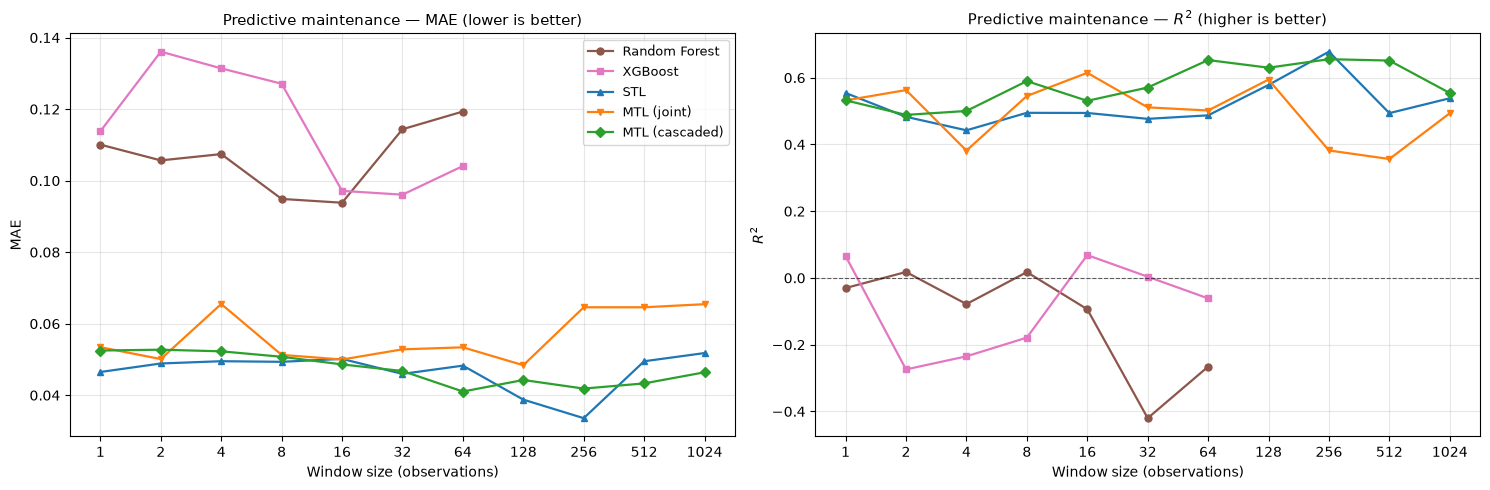

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_metric(pdm_mae, "mae", "MAE", "Predictive maintenance — MAE (lower is better)", None, ax=axes[0])
plot_metric(pdm_r2,  "r2",  r"$R^2$", "Predictive maintenance — $R^2$ (higher is better)", None, ax=axes[1])
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
axes[0].legend(fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "results_pdm.png"), dpi=DPI, bbox_inches="tight")
print("wrote", os.path.join(IMG_DIR, "results_pdm.png"))
plt.show()

## Best configuration per task

Feeds `Table~\ref{tab:results_best}`, the single table summarising the chapter.

In [13]:
SPEC = [("Anomaly detection", "ad",  ad_f1,   "f1",      "F1-score"),
        ("Fault detection",   "fd",  fd_f1,   "mean_f1", "Mean F1-score"),
        ("Predictive maint.", "pdm", pdm_r2,  "r2",      "$R^2$")]

rows = []
for task_label, task, table, metric, metric_label in SPEC:
    for name in MODELS:
        ws, v = best_of(table[name], metric)
        rows.append({"Task": task_label, "Metric": metric_label,
                     "Model": name, "Best window": ws, "Value": v})
best = pd.DataFrame(rows)

lines = [
    "% Auto-generated by results.ipynb -- do not edit by hand",
    r"\begin{tabular}{lllrr}",
    r"\hline",
    r"\textbf{Task} & \textbf{Metric} & \textbf{Model} & \textbf{Best window} & \textbf{Value} \\",
    r"\hline",
]
prev = None
for _, r in best.iterrows():
    task_cell = r["Task"] if r["Task"] != prev else ""
    metric_cell = r["Metric"] if r["Task"] != prev else ""
    prev = r["Task"]
    if task_cell == "" and len(lines) > 5 and lines[-1] == r"\hline":
        pass
    lines.append(f"{task_cell} & {metric_cell} & {r['Model']} & {r['Best window']:,} & {r['Value']:.3f} \\\\")
    if r["Model"] == list(MODELS)[-1]:
        lines.append(r"\hline")
lines.append(r"\end{tabular}")
with open(os.path.join(TABLE_DIR, "results_best.tex"), "w") as fh:
    fh.write("\n".join(lines) + "\n")
print("wrote", os.path.join(TABLE_DIR, "results_best.tex"))

best.round(3)

wrote ../tables/results_best.tex


,Task,Metric,Model,Best window,Value
0,Anomaly detection,F1-score,Random Forest,32,0.441
1,Anomaly detection,F1-score,XGBoost,32,0.460
2,Anomaly detection,F1-score,STL,64,0.900
3,Anomaly detection,F1-score,MTL (joint),128,0.885
4,Anomaly detection,F1-score,MTL (cascaded),128,0.889
5,Fault detection,Mean F1-score,Random Forest,32,0.483
6,Fault detection,Mean F1-score,XGBoost,64,0.504
7,Fault detection,Mean F1-score,STL,16,0.701
8,Fault detection,Mean F1-score,MTL (joint),256,0.640
9,Fault detection,Mean F1-score,MTL (cascaded),64,0.720


---

All tables written to `../tables/` and all figures to `../imgs/`.
Re-run the whole notebook after any change to the result files.